# Individual Assignment I
## Data Preparation and Pipeline Design
### Viktoriia Stepanenko

The tasks in this notebook are executed in a deliberate order that reflects 
three core principles: respecting the temporal logic of prediction (no 
information available after prediction time may be used as input), 
preserving the independence of training, validation, and test sets, and 
ensuring that all data-driven transformations are fitted exclusively on 
training data. This ordering prevents both preprocessing leakage and target 
leakage, and guarantees that model evaluation reflects realistic performance.

## Task 1 – Identify the Prediction Target

**Task requirements:**
- Inspect the dataset and identify the correct target variable.
- Justify why it is the appropriate prediction objective.
- Identify at least two variables that could superficially appear to be 
  valid targets and explain why they should not be used.

The central concept that guides target identification is the **prediction 
time constraint**: in a supervised learning setting, the target variable 
must represent an outcome that is *unknown at the moment a prediction is 
requested*, while all input features must be *observable before that 
moment*. Violating this constraint, whether in the target or in the 
features, introduces **target leakage** and produces a model that cannot 
generalise to real-world deployment.

In this dataset, the correct target variable is `y`, a binary column 
encoding whether a given client subscribed to a term deposit following 
a telemarketing contact (`yes` / `no`). This is the appropriate prediction 
objective for two reasons. First, it directly represents the business 
outcome the bank is trying to anticipate: before deciding whether to 
contact a client, the bank wants to estimate the probability of a 
successful subscription. Second, `y` is observed strictly *after* the 
interaction concludes — it is never available at prediction time — which 
satisfies the formal requirement for a valid label in the supervised 
learning framework.

Two other variables could appear to be relevant targets but must not be 
treated as such:

**`duration`** records the length of the last phone call in seconds. It 
may superficially seem like a useful proxy for client engagement — longer 
calls plausibly correlate with higher interest. However, call duration is 
only measurable *after the call has ended*, meaning it is unavailable at 
the moment the bank decides whether to place a call. More critically, 
duration is strongly correlated with the outcome itself: calls of zero 
seconds always result in `y = no`, and longer calls are systematically 
associated with subscriptions. Treating it as an input feature — let alone 
a target — would constitute target leakage and render the model useless in 
production. `duration` will be dropped entirely before any further 
processing.

**`pdays`** records the number of days since the client was last contacted 
in a *previous* campaign, with the value `999` used as a sentinel to 
indicate that the client was never previously contacted. While `pdays` 
remains as an input feature (it is observable before the call), it could 
be mistakenly treated as a target because it summarises a key aspect of 
the client relationship. It is not, however, the outcome the bank is 
trying to predict — it describes history, not the future subscription 
decision — and so it does not qualify as a valid prediction target.

In [4]:
# Task 1 – Identify Prediction Target

TARGET = 'y'

# 'duration' is post-call information only available after the outcome
# is already determined. It must be removed before any other step.
LEAKY_FEATURES = ['duration']

print(f"Target variable : '{TARGET}'")
print(f"Leaky features  : {LEAKY_FEATURES}")
print(f"\n'duration' will be dropped at load time to prevent any risk")
print(f"of it influencing downstream transformations.")

Target variable : 'y'
Leaky features  : ['duration']

'duration' will be dropped at load time to prevent any risk
of it influencing downstream transformations.


## Task 2 – Data Loading and Exploration

**Task requirements:**
- Load the dataset and inspect its structure (shape, types, summary statistics).
- Identify numerical and categorical variables.
- Analyze the target variable distribution and comment on class imbalance.
- Detect explicit and implicit missing values.
- Visualize at least two numerical and two categorical variables, each supporting a specific observation.
- Identify at least one variable requiring special consideration before modelling.

Exploratory Data Analysis (EDA) serves a precise purpose: to surface structural 
properties of the data that will directly inform every subsequent pipeline decision. 
Each inspection below is conducted with a specific question in mind, not as a 
mechanical checklist.

**Important technical note:** `bank-additional.csv` uses semicolons as field 
separators, not commas. This is common in European datasets where commas serve 
as decimal separators. Failing to specify `sep=';'` would load the entire row 
as a single column.

**Data source and file location.** I use the smaller UCI Bank Marketing dataset
(`bank-additional.csv`) downloaded from Kaggle. The CSV file is stored in the
same directory as this notebook (`ML-fundamentals-2026`), so that it can be
loaded directly using a relative path. The dataset uses semicolons as field
separators, therefore I must set `sep=';'` when reading it with Pandas.

Shape BEFORE dropping leaky features : (4119, 21)
Shape AFTER dropping leaky features  : (4119, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic summary statistics for numerical variables:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Numerical columns:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Target distribution (counts):
y
no     3668
yes     451
Name: count, dtype: int64

Target distribution (proportions):
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Explicit missing values (NaN) per column:
Series([], dtype: int64)

Implicit missing values ('unknown') in categorical columns:


/var/folders/ng/xzc15g2s1n3bgp3b496pcxth0000gn/T/ipykernel_67088/1864338927.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


,count,fraction
default,803,0.194950
education,167,0.040544
housing,105,0.025492
loan,105,0.025492
job,39,0.009468
marital,11,0.002671


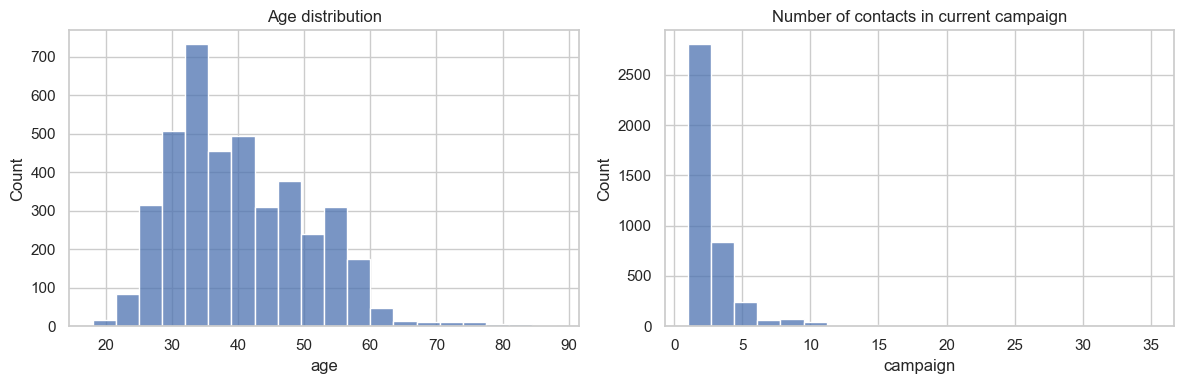

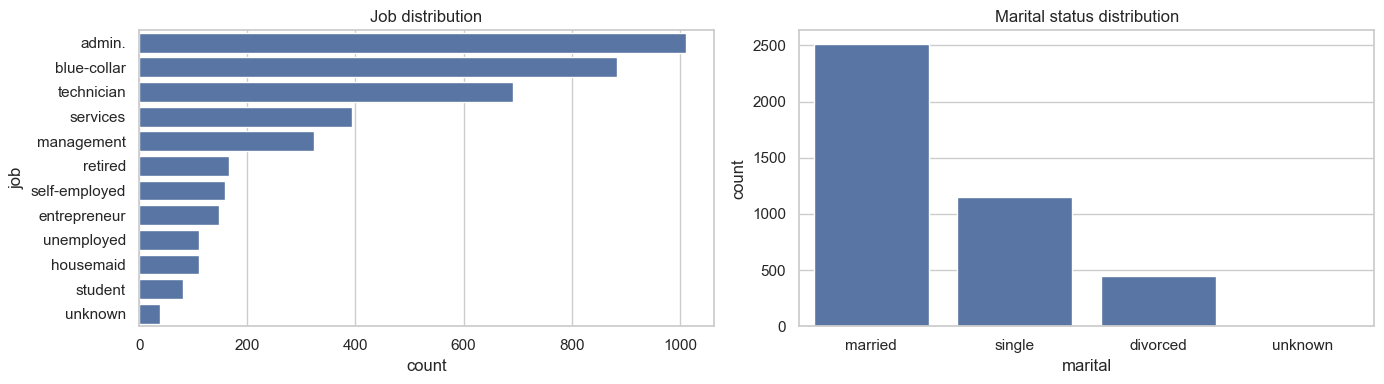


'pdays' value counts (sorted):
pdays
0      2
1      3
2      4
3     52
4     14
5      4
6     42
7     10
9      3
10     8
Name: count, dtype: int64

Note: 'pdays' uses 999 as a sentinel for 'never contacted before'. This means 'pdays' mixes genuine measurements with a special code, so it will require special handling in the missing-value step.


In [ ]:
# Task 2 – Data Loading and Exploration

# I start by importing the libraries I need for this task.
# - pathlib: to handle file paths in a clean way
# - numpy and pandas: for numerical work and table operations
# - matplotlib and seaborn: for visualizations during exploration
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# I define the path to the CSV file. The file 'bank-additional.csv'
# is placed in the same folder as this notebook (ML-fundamentals-2026).
DATA_PATH = Path("bank-additional.csv")

# This explicit check makes the notebook fail early with a clear message
# if the CSV is not in the expected location. This helps avoid silent errors.
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Place 'bank-additional.csv' in the same folder as this notebook "
        "or update DATA_PATH to the correct location."
    )

# 1. Load the raw data from CSV.
# Important: the dataset uses semicolons (';') as separators, so I must set sep=';'.
raw_df = pd.read_csv(DATA_PATH, sep=";")

print("Shape BEFORE dropping leaky features :", raw_df.shape)

# Immediately after loading, I remove the leaky feature 'duration'.
# This ensures that no later exploratory step or transformation can
# accidentally use information that would not be available at prediction time.
df = raw_df.drop(columns=LEAKY_FEATURES)

print("Shape AFTER dropping leaky features  :", df.shape)

# I display the first few rows to get a concrete feeling for the data.
display(df.head())

# 2. Inspect the structure of the dataset.
# I look at the data types to distinguish numerical and categorical variables.
print("\nData types:")
print(df.dtypes)

# For numerical variables, I compute basic summary statistics
# (mean, std, quartiles, etc.) to understand scales and distributions.
print("\nBasic summary statistics for numerical variables:")
display(df.describe())

# 3. Identify numerical and categorical variables automatically.
# This separation will be important later for scaling (numerical)
# and encoding (categorical).
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nNumerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

# 4. Analyze the target variable distribution to check for class imbalance.
print("\nTarget distribution (counts):")
print(df[TARGET].value_counts())

print("\nTarget distribution (proportions):")
print(df[TARGET].value_counts(normalize=True))

# 5. Detect explicit and implicit missing values.

# Explicit missingness: entries that are actually NaN.
print("\nExplicit missing values (NaN) per column:")
missing_counts = df.isna().sum()
print(missing_counts[missing_counts > 0])

# Implicit missingness: categorical values encoded as 'unknown'.
# For each categorical column, I count how often 'unknown' appears.
print("\nImplicit missing values ('unknown') in categorical columns:")
unknown_stats = {}
for col in cat_cols:
    mask = df[col] == "unknown"
    if mask.any():
        unknown_stats[col] = {
            "count": int(mask.sum()),
            "fraction": float(mask.mean()),
        }

unknown_stats_df = pd.DataFrame.from_dict(unknown_stats, orient="index")
display(unknown_stats_df.sort_values("fraction", ascending=False))

# 6. Visualize distributions for two numerical and two categorical variables.
# The goal is not to create many plots, but a few that support concrete observations.

# Numerical variables: 'age' and 'campaign'.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["age"], kde=False, bins=20, ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(df["campaign"], kde=False, bins=20, ax=axes[1])
axes[1].set_title("Number of contacts in current campaign")
plt.tight_layout()
plt.show()

# Categorical variables: 'job' and 'marital'.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(
    y="job",
    data=df,
    order=df["job"].value_counts().index,
    ax=axes[0],
)
axes[0].set_title("Job distribution")

sns.countplot(
    x="marital",
    data=df,
    order=df["marital"].value_counts().index,
    ax=axes[1],
)
axes[1].set_title("Marital status distribution")
plt.tight_layout()
plt.show()

# 7. Highlight a variable that requires special consideration: 'pdays'.
# The value 999 does not represent an ordinary number of days; it is a sentinel
# meaning "the client was never contacted before". This is an example of
# implicit missingness / special coding that must be handled carefully later.
pdays_values = df["pdays"].value_counts().sort_index()
print("\n'pdays' value counts (sorted):")
print(pdays_values.head(10))

print(
    "\nNote: 'pdays' uses 999 as a sentinel for 'never contacted before'. "
    "This means 'pdays' mixes genuine measurements with a special code, "
    "so it will require special handling in the missing-value step."
)

### Summary of data exploration

The dataset contains 4,119 observations and 21 original features. After
dropping `duration` to avoid target leakage, I work with 20 features plus
the target `y`. The table includes a mix of numerical variables (e.g., `age`,
`campaign`, `pdays`, macroeconomic indicators) and categorical variables
(e.g., `job`, `marital`, `education`, `contact`, `month`).

The target `y` is clearly imbalanced: the majority of clients did **not**
subscribe to a term deposit, and only a relatively small fraction said "yes".
This confirms that class imbalance will be an important issue later when I
design the training and evaluation procedure.

There are no substantial explicit NaN values, but several categorical
variables use the label `unknown` (for example in `job`, `education`,
`housing`, and `loan`). These are examples of **implicit missingness**:
the entry is present in the table, but it really means "information not
available". I will decide later whether to treat `unknown` as a separate
category or to model missingness in some other way.

The variable `pdays` deserves special attention. Most entries take the
value 999, which does not represent a genuine number of days but a sentinel
meaning "the client was never contacted before". This means `pdays` mixes
meaningful measurements (actual days since last contact) with a special
code for "no previous contact". I will handle this carefully in the
missing-value and feature-engineering steps to avoid misleading the model.

## Task 3 – Data Splitting

The goal of this step is to separate the data into training, validation, and
test sets **before** I fit any data-driven transformations. This prevents
data leakage: the model and all preprocessing steps will only "see" the
training data when learning parameters.

I use a stratified split with respect to the target `y` so that the class
imbalance (many "no" and fewer "yes") is preserved in all three sets. This
makes the validation and test performance more representative of the real
deployment setting.

In [6]:
# Task 3 – Data Splitting (Stratified)

# In this step I create three disjoint datasets:
# - train: used to fit all models and data-driven transformations
# - validation: used to tune choices and evaluate during development
# - test: used once at the very end as a final check

from sklearn.model_selection import train_test_split

# I start by separating features (X) from the target (y).
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Full dataset shape:")
print("X:", X.shape, " y:", y.shape)

# First, I create a temporary split:
# - 80% of the data goes into X_temp / y_temp (train + validation)
# - 20% is held out immediately as the test set
# I use stratify=y to keep the same yes/no ratio in each split.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

# Second, I split X_temp / y_temp into train and validation.
# I choose 75% of X_temp for training and 25% for validation.
# Combined with the first step, this gives:
# - 60% train
# - 20% validation
# - 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,  # 0.25 of 0.80 = 0.20 of the full data
    stratify=y_temp,
    random_state=42,
)

print("\nFinal split shapes:")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

# I also check the class distribution in each split to verify that
# stratification preserved the imbalance pattern.
def show_class_distribution(name, y_part):
    counts = y_part.value_counts()
    props = y_part.value_counts(normalize=True)
    print(f"\n{name} set class distribution:")
    print("Counts:")
    print(counts)
    print("Proportions:")
    print(props)

show_class_distribution("Train", y_train)
show_class_distribution("Validation", y_val)
show_class_distribution("Test", y_test)

print(
    "\nFrom this point on, any transformation that learns from data "
    "(imputation, encoding, scaling, resampling, feature selection, and "
    "model fitting) will be fitted **only** on the training set and then "
    "applied to the validation and test sets."
)

Full dataset shape:
X: (4119, 19)  y: (4119,)

Final split shapes:
X_train: (2471, 19)  y_train: (2471,)
X_val  : (824, 19)  y_val  : (824,)
X_test : (824, 19)  y_test : (824,)

Train set class distribution:
Counts:
y
no     2200
yes     271
Name: count, dtype: int64
Proportions:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation set class distribution:
Counts:
y
no     734
yes     90
Name: count, dtype: int64
Proportions:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test set class distribution:
Counts:
y
no     734
yes     90
Name: count, dtype: int64
Proportions:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

From this point on, any transformation that learns from data (imputation, encoding, scaling, resampling, feature selection, and model fitting) will be fitted **only** on the training set and then applied to the validation and test sets.


The final split uses approximately 60% of the data for training,
20% for validation, and 20% for testing. Because I use
`stratify=y` in both splitting steps, the proportion of positive
cases (`y = "yes"`) remains around 11% in all three sets. This
preserves the original class imbalance and makes the validation
and test performance more representative of the real deployment
scenario. All later data-driven steps (imputation, encoding,
scaling, resampling, feature selection, and model training) will
be fitted on `X_train` / `y_train` only.

## Task 4 – Managing Missing Values

In this step I make missing values explicit and decide how to handle them.
The key rule is that any operation that *learns* something from the data
(such as computing medians or most-frequent categories) must be fitted on
the **training set only** and then applied to the validation and test sets.

The dataset contains:
- almost no explicit `NaN` values;
- several categorical variables that use `unknown` as an implicit missing value;
- the numerical variable `pdays`, which uses the sentinel value `999` to
  mean "the client was never contacted before".

I treat `unknown` as a meaningful category and keep it as-is, because the
fact that information is missing can itself be predictive. For `pdays`,
I create an indicator column flagging "never contacted before", and then
replace `999` with `NaN` and impute numerical variables using medians
computed from the training set.

In [ ]:
# Task 4 – Managing Missing Values (fit on train)

from sklearn.impute import SimpleImputer

# I start from the train/val/test splits created in Task 3.
# X_train, X_val, X_test, y_train, y_val, y_test are already defined.

# 1. Identify numerical and categorical columns using the training set.
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = <whatever_was_before>.select_dtypes(include=["object"]).columns.tolist()
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# 2. Handle the special sentinel value in 'pdays'.
# The value 999 means "never contacted before", not an actual number of days.
# I create a binary indicator column that records this fact. This is a
# modeling decision: I explicitly preserve the information that there was
# no previous contact.
for split_name, X_part in [
    ("train", X_train),
    ("val", X_val),
    ("test", X_test),
]:
    X_part["pdays_never_contacted"] = (X_part["pdays"] == 999).astype(int)

# Now I replace 999 by NaN in 'pdays' so that it can be imputed like
# other numerical missing values.
for split_name, X_part in [
    ("train", X_train),
    ("val", X_val),
    ("test", X_test),
]:
    X_part.loc[X_part["pdays"] == 999, "pdays"] = np.nan

# 3. Impute numerical variables.
# I fit a SimpleImputer on the training data only, using the median for
# each numerical column. The fitted medians are then applied to the
# validation and test sets.
num_imputer = SimpleImputer(strategy="median")
num_imputer.fit(X_train[num_cols])

X_train[num_cols] = num_imputer.transform(X_train[num_cols])
X_val[num_cols]   = num_imputer.transform(X_val[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

# 4. Impute categorical variables (only if there are explicit NaNs).
# Here I treat the string 'unknown' as a real category, so I do NOT change it.
# I only replace true NaN entries, using the most frequent category learned
# from the training set.
cat_imputer = SimpleImputer(strategy="most_frequent")
cat_imputer.fit(X_train[cat_cols])

X_train[cat_cols] = cat_imputer.transform(X_train[cat_cols])
X_val[cat_cols]   = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

# 5. Sanity check: count remaining missing values after imputation.
def show_remaining_missing(name, X_part):
    missing_per_col = X_part.isna().sum()
    missing_per_col = missing_per_col[missing_per_col > 0]
    print(f"\nRemaining missing values in {name} set:")
    if missing_per_col.empty:
        print("None")
    else:
        print(missing_per_col)

show_remaining_missing("train", X_train)
show_remaining_missing("validation", X_val)
show_remaining_missing("test", X_test)

print(
    "\nMissing-value handling is now complete. All imputers were fitted "
    "on the training set only, and then applied to validation and test."
)

Numerical columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Remaining missing values in train set:
None

Remaining missing values in validation set:
None

Remaining missing values in test set:
None

Missing-value handling is now complete. All imputers were fitted on the training set only, and then applied to validation and test.


/var/folders/ng/xzc15g2s1n3bgp3b496pcxth0000gn/T/ipykernel_67088/1922386652.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


## Task 5 – Encoding Categorical Variables

The dataset contains several categorical variables such as `job`, `marital`,
`education`, `contact`, and `month`. Some of these are purely nominal
(categories without order), while others such as `education` have an
intuitive order (e.g., basic education < high school < university degree).

For this assignment I use **one-hot encoding** for all categorical variables.
This means I create a separate 0/1 column for each category. I deliberately
do not encode `education` as integers in increasing order, because that would
imply equal spacing between levels (for example, that the "distance" between
basic education and high school is the same as between high school and
university). One-hot encoding is safer and matches the linearity assumptions
of Logistic Regression.

All encoders are fitted on the **training set only** and then applied to the
validation and test sets, which prevents information from leaking out of the
training data.

In [ ]:
# Task 5 – Encoding Categorical Variables (fit on train)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# I identify categorical columns from the training set.
select_dtypes(include=["object"])
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical columns to be one-hot encoded:")
print(cat_cols)
print("\nNumerical columns to be passed through unchanged at this stage:")
print(num_cols)

# I use OneHotEncoder to turn each category into a 0/1 indicator column.
# - handle_unknown='ignore' ensures that if a new category appears in
#   validation or test data, the encoder will not crash; it will simply
#   produce zeros for that unseen category.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# ColumnTransformer lets me apply different transformations to different
# column groups in a single object:
# - 'cat' transformer: one-hot encodes the categorical columns
# - 'num' transformer: passes numerical columns through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# I fit the encoder on the training set only.
preprocessor.fit(X_train)

# Then I transform train, validation, and test using the fitted encoders.
X_train_encoded = preprocessor.transform(X_train)
X_val_encoded   = preprocessor.transform(X_val)
X_test_encoded  = preprocessor.transform(X_test)

# For interpretability, I recover meaningful feature names from the transformer
# and wrap the encoded arrays back into DataFrames.
feature_names = preprocessor.get_feature_names_out()

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index,
)
X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=feature_names,
    index=X_val.index,
)
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index,
)

print("\nEncoded feature matrix shapes:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_val_encoded  :", X_val_encoded.shape)
print("X_test_encoded :", X_test_encoded.shape)

print(
    "\nCategorical encoding is complete. All encoders were fitted on the "
    "training set only, and the same transformation was applied to "
    "validation and test."
)

Categorical columns to be one-hot encoded:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns to be passed through unchanged at this stage:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_never_contacted']

Encoded feature matrix shapes:
X_train_encoded: (2471, 62)
X_val_encoded  : (824, 62)
X_test_encoded : (824, 62)

Categorical encoding is complete. All encoders were fitted on the training set only, and the same transformation was applied to validation and test.
